Original Dataset Shape:
(4177, 9)

First 5 rows:
  Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  Rings  
0         0.150     15  
1         0.070      7  
2         0.210      9  
3         0.155     10  
4         0.055      7  


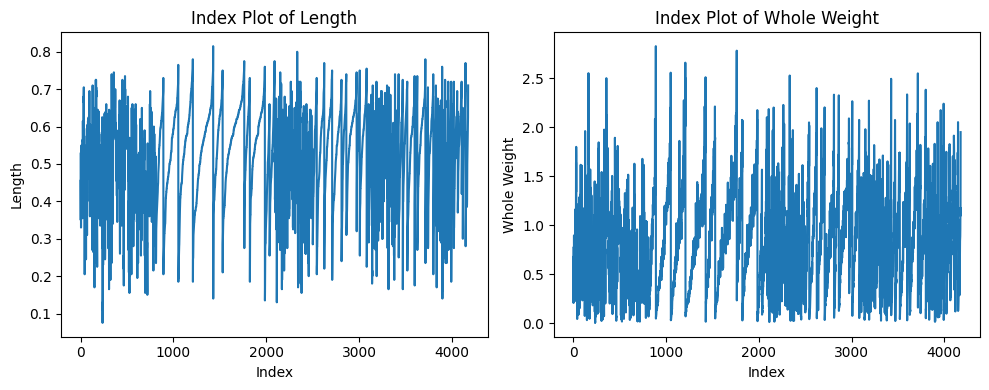

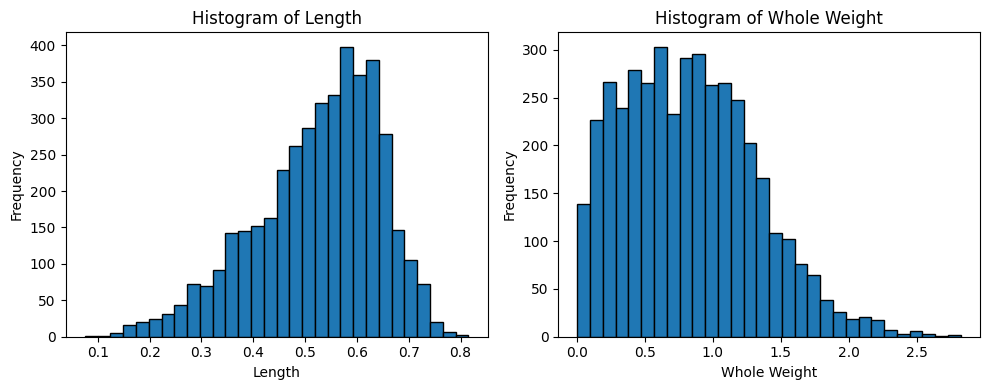

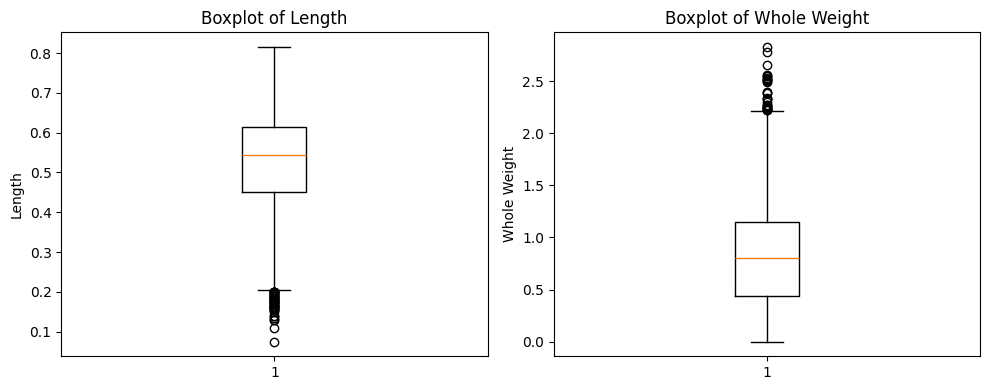


--- Length Descriptive Statistics ---
Min: 0.075
Q1: 0.45
Median: 0.545
Q3: 0.615
Max: 0.815
IQR: 0.16499999999999998

--- Whole Weight Descriptive Statistics ---
Min: 0.002
Q1: 0.4415
Median: 0.7995
Q3: 1.153
Max: 2.8255
IQR: 0.7115

--- Length Moment-Based Statistics ---
Mean: 0.5239920995930094
Standard Deviation: 0.12009291256479956
Variance: 0.014422307648296592
Skewness: -0.639873268981801
Kurtosis: 0.06462097389494126

--- Whole Weight Moment-Based Statistics ---
Mean: 0.8287421594445774
Standard Deviation: 0.4903890182309977
Variance: 0.24048138920156176
Skewness: 0.5309585632523087
Kurtosis: -0.02364350426998163


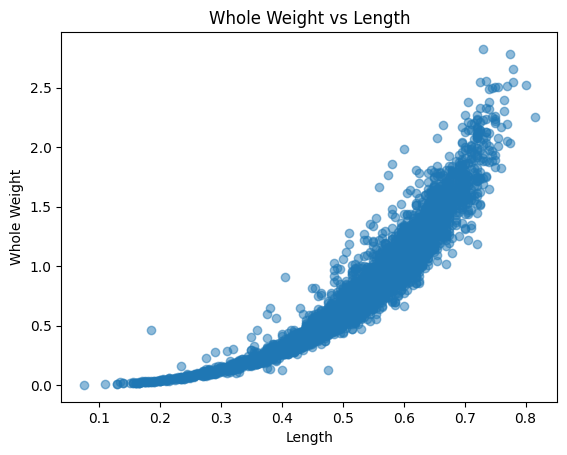


Number of Outliers:
79

Outlier Rows:
     Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  \
148    I   0.175     0.130   0.055        0.0315          0.0105   
149    I   0.170     0.130   0.095        0.0300          0.0130   
165    M   0.725     0.570   0.190        2.5500          1.0705   
236    I   0.075     0.055   0.010        0.0020          0.0010   
237    I   0.130     0.100   0.030        0.0130          0.0045   
...   ..     ...       ...     ...           ...             ...   
3837   I   0.170     0.105   0.035        0.0340          0.0120   
3899   I   0.140     0.105   0.035        0.0145          0.0050   
3902   I   0.160     0.120   0.020        0.0180          0.0075   
3993   M   0.720     0.600   0.235        2.2385          0.9840   
3994   I   0.185     0.135   0.045        0.0320          0.0110   

      Viscera_weight  Shell_weight  Rings  
148           0.0065        0.0125      5  
149           0.0080        0.0100      4  
165         

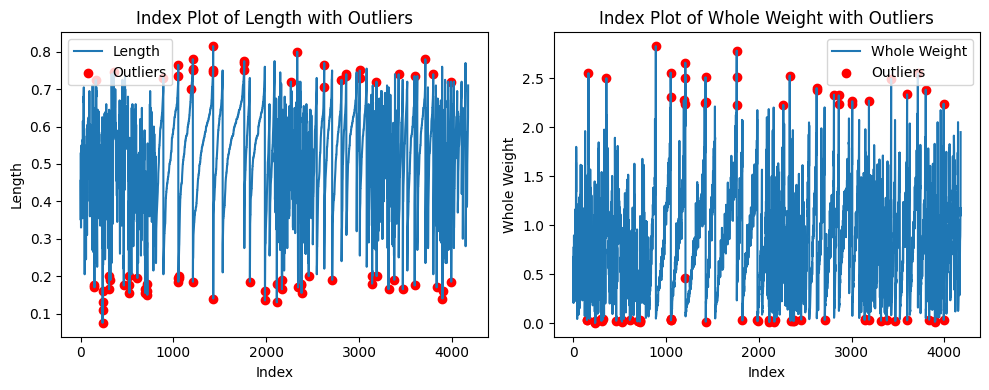

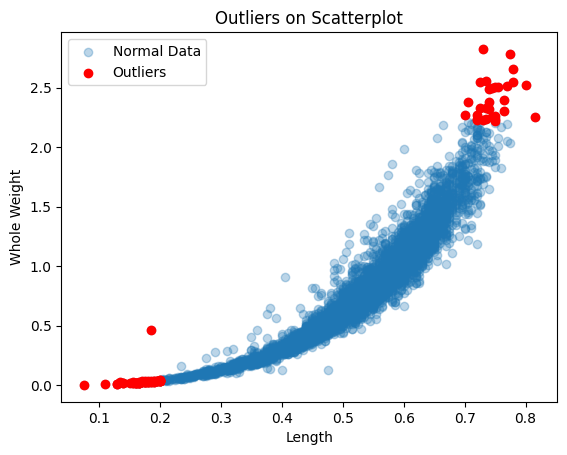


Clean Dataset Shape After Removing Outliers:
(4098, 9)

--- Second Statistics Table After Removing Outliers ---
          Length  Whole_weight
min     0.205000      0.038500
max     0.775000      2.210000
median  0.545000      0.802500
mean    0.526596      0.826711
std     0.113225      0.468145
var     0.012820      0.219159
skew   -0.533827      0.406031
kurt   -0.299837     -0.447007


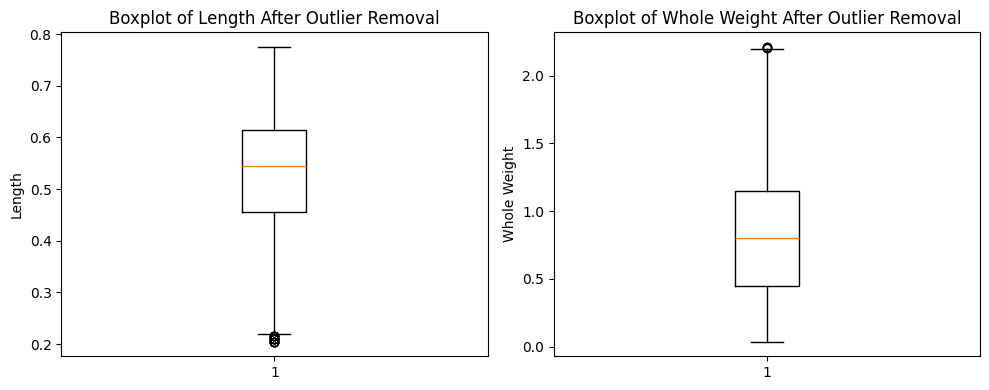

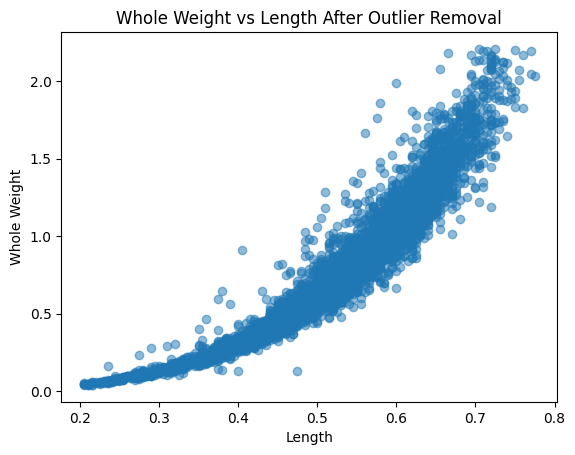

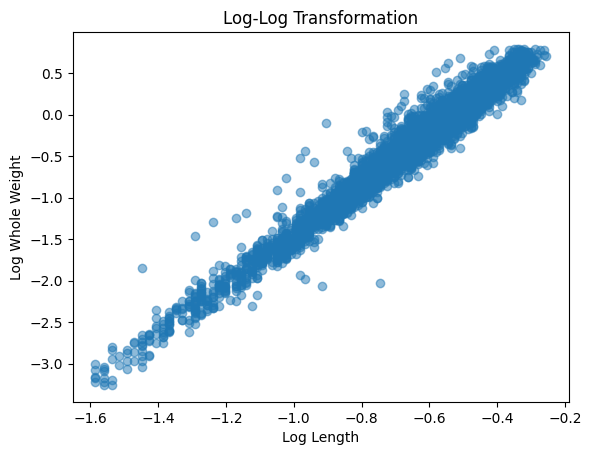


--- Regression Results ---
Intercept: 1.6233696531163402
Coefficient: 3.0441696069243522
R2: 0.96378216125664
MSE: 0.020495829828479625


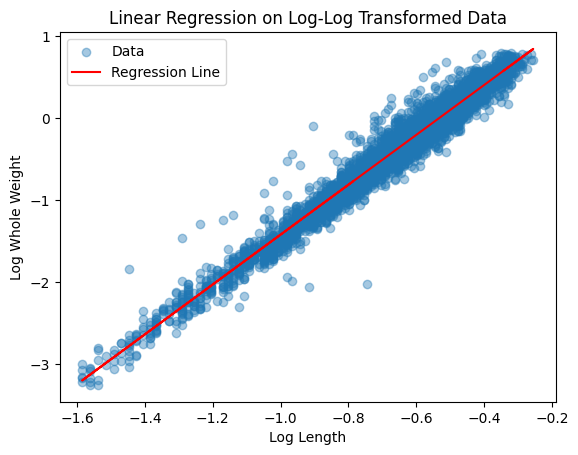

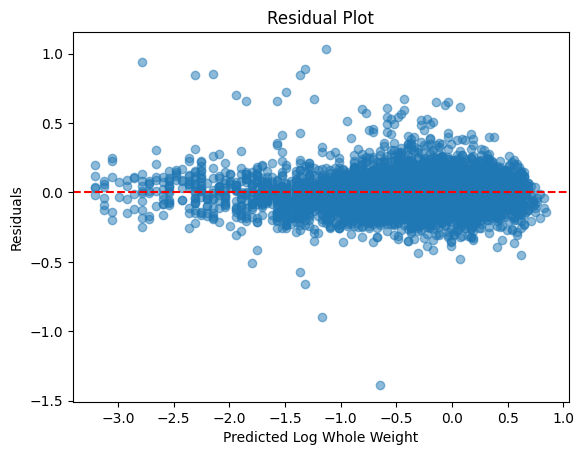


--- Residual Statistics ---
Residual Mean: 2.9259171952053907e-17
Residual Standard Deviation: 0.14318111772100175
Residual Variance: 0.020500832471835366


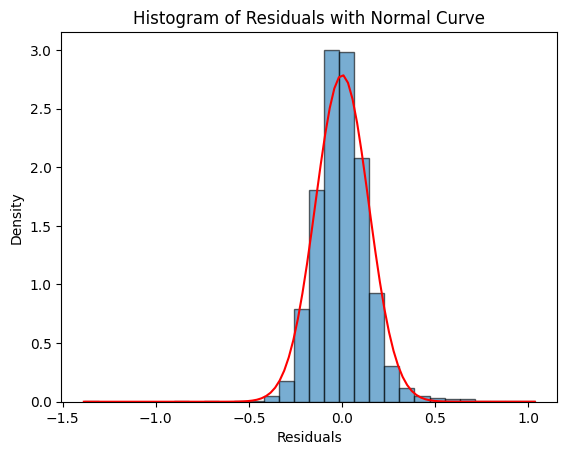

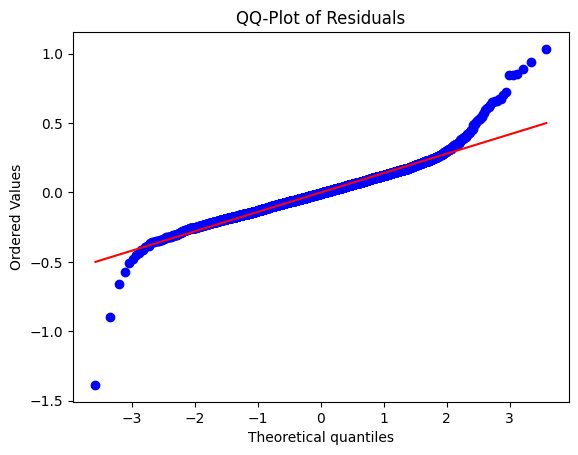

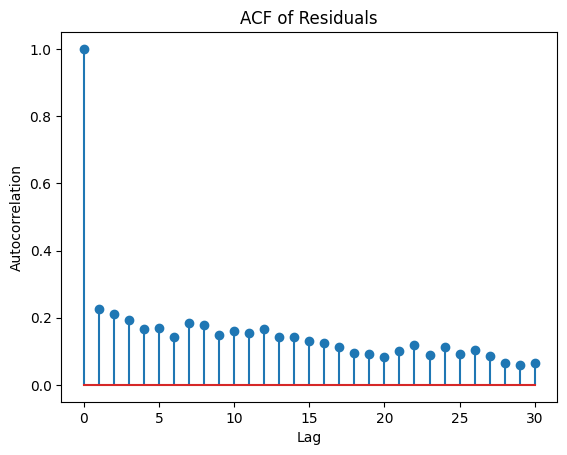

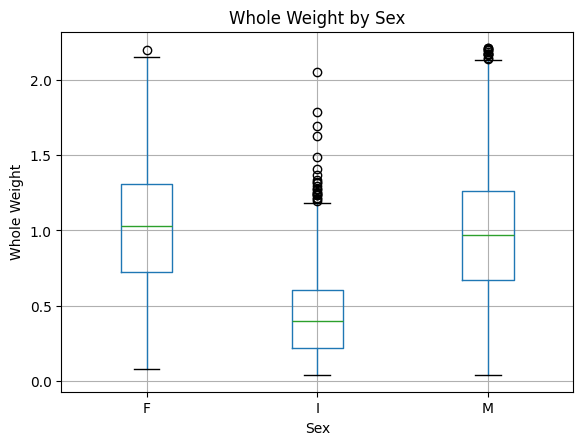

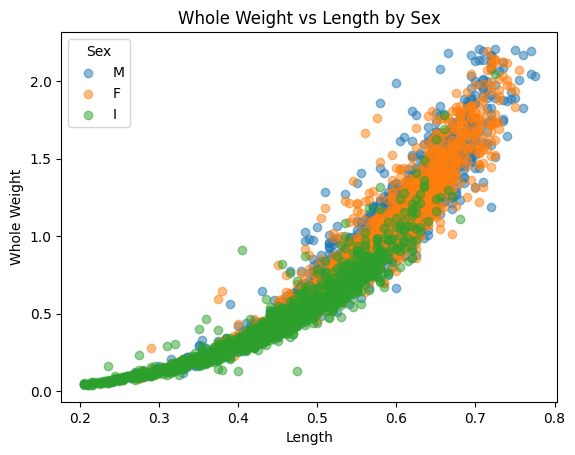

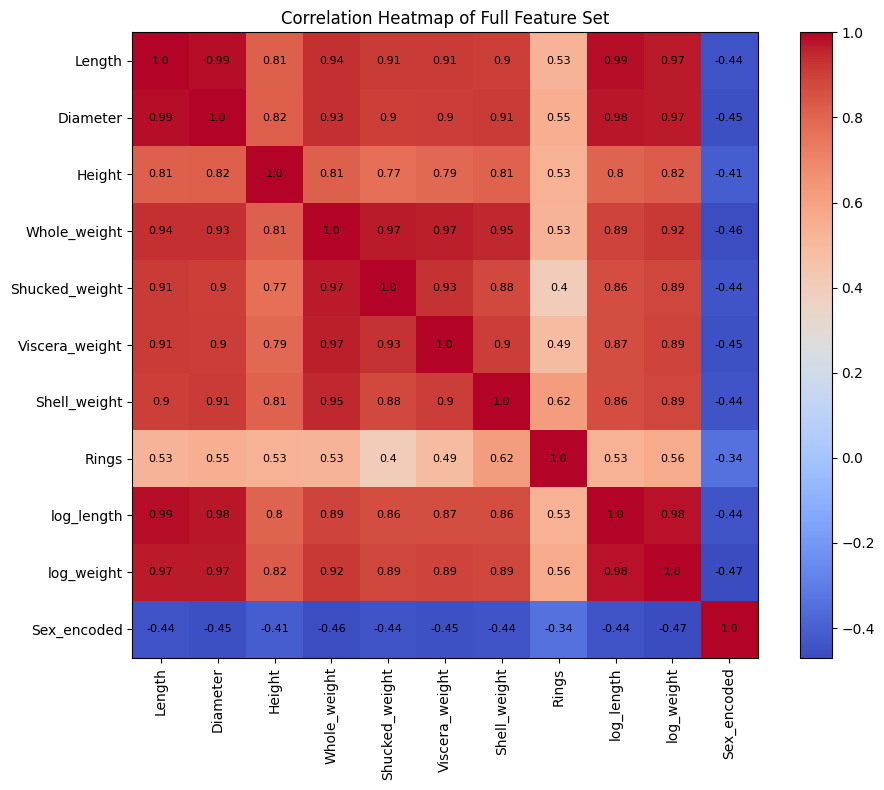

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



df = pd.read_csv("abalone.data", header=None)

df.columns = ["Sex", "Length", "Diameter", "Height",
              "Whole_weight", "Shucked_weight",
              "Viscera_weight", "Shell_weight", "Rings"]

print("Original Dataset Shape:")
print(df.shape)

print("\nFirst 5 rows:")
print(df.head())


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(df.index, df["Length"])
plt.title("Index Plot of Length")
plt.xlabel("Index")
plt.ylabel("Length")

plt.subplot(1, 2, 2)
plt.plot(df.index, df["Whole_weight"])
plt.title("Index Plot of Whole Weight")
plt.xlabel("Index")
plt.ylabel("Whole Weight")

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df["Length"], bins=30, edgecolor="black")
plt.title("Histogram of Length")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(df["Whole_weight"], bins=30, edgecolor="black")
plt.title("Histogram of Whole Weight")
plt.xlabel("Whole Weight")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot(df["Length"])
plt.title("Boxplot of Length")
plt.ylabel("Length")

plt.subplot(1, 2, 2)
plt.boxplot(df["Whole_weight"])
plt.title("Boxplot of Whole Weight")
plt.ylabel("Whole Weight")

plt.tight_layout()
plt.show()

def get_descriptive_stats(data, name):
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    print(f"\n--- {name} Descriptive Statistics ---")
    print(f"Min: {data.min()}")
    print(f"Q1: {q1}")
    print(f"Median: {data.median()}")
    print(f"Q3: {q3}")
    print(f"Max: {data.max()}")
    print(f"IQR: {iqr}")


get_descriptive_stats(df["Length"], "Length")
get_descriptive_stats(df["Whole_weight"], "Whole Weight")


def get_moments(data, name):
    print(f"\n--- {name} Moment-Based Statistics ---")
    print(f"Mean: {data.mean()}")
    print(f"Standard Deviation: {data.std()}")
    print(f"Variance: {data.var()}")
    print(f"Skewness: {data.skew()}")
    print(f"Kurtosis: {data.kurt()}")


get_moments(df["Length"], "Length")
get_moments(df["Whole_weight"], "Whole Weight")


plt.figure()
plt.scatter(df["Length"], df["Whole_weight"], alpha=0.5)
plt.xlabel("Length")
plt.ylabel("Whole Weight")
plt.title("Whole Weight vs Length")
plt.show()


# Outlier limits for Length
Q1_L = df["Length"].quantile(0.25)
Q3_L = df["Length"].quantile(0.75)
IQR_L = Q3_L - Q1_L

lower_L = Q1_L - 1.5 * IQR_L
upper_L = Q3_L + 1.5 * IQR_L

# Outlier limits for Whole_weight
Q1_W = df["Whole_weight"].quantile(0.25)
Q3_W = df["Whole_weight"].quantile(0.75)
IQR_W = Q3_W - Q1_W

lower_W = Q1_W - 1.5 * IQR_W
upper_W = Q3_W + 1.5 * IQR_W

# Find outliers in either Length or Whole_weight
outliers = df[
    (df["Length"] < lower_L) | (df["Length"] > upper_L) |
    (df["Whole_weight"] < lower_W) | (df["Whole_weight"] > upper_W)
]

print("\nNumber of Outliers:")
print(len(outliers))

print("\nOutlier Rows:")
print(outliers)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(df.index, df["Length"], label="Length")
plt.scatter(outliers.index, outliers["Length"], color="red", label="Outliers")
plt.title("Index Plot of Length with Outliers")
plt.xlabel("Index")
plt.ylabel("Length")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df.index, df["Whole_weight"], label="Whole Weight")
plt.scatter(outliers.index, outliers["Whole_weight"], color="red", label="Outliers")
plt.title("Index Plot of Whole Weight with Outliers")
plt.xlabel("Index")
plt.ylabel("Whole Weight")
plt.legend()

plt.tight_layout()
plt.show()


plt.figure()
plt.scatter(df["Length"], df["Whole_weight"], label="Normal Data", alpha=0.3)
plt.scatter(outliers["Length"], outliers["Whole_weight"],
            color="red", label="Outliers")
plt.xlabel("Length")
plt.ylabel("Whole Weight")
plt.title("Outliers on Scatterplot")
plt.legend()
plt.show()

df_clean = df.drop(outliers.index)

print("\nClean Dataset Shape After Removing Outliers:")
print(df_clean.shape)


clean_stats = df_clean[["Length", "Whole_weight"]].agg([
    "min",
    "max",
    "median",
    "mean",
    "std",
    "var",
    "skew",
    "kurt"
])

print("\n--- Second Statistics Table After Removing Outliers ---")
print(clean_stats)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot(df_clean["Length"])
plt.title("Boxplot of Length After Outlier Removal")
plt.ylabel("Length")

plt.subplot(1, 2, 2)
plt.boxplot(df_clean["Whole_weight"])
plt.title("Boxplot of Whole Weight After Outlier Removal")
plt.ylabel("Whole Weight")

plt.tight_layout()
plt.show()


plt.figure()
plt.scatter(df_clean["Length"], df_clean["Whole_weight"], alpha=0.5)
plt.xlabel("Length")
plt.ylabel("Whole Weight")
plt.title("Whole Weight vs Length After Outlier Removal")
plt.show()


df_clean = df_clean[
    (df_clean["Length"] > 0) &
    (df_clean["Whole_weight"] > 0)
]

df_clean["log_length"] = np.log(df_clean["Length"])
df_clean["log_weight"] = np.log(df_clean["Whole_weight"])

plt.figure()
plt.scatter(df_clean["log_length"], df_clean["log_weight"], alpha=0.5)
plt.xlabel("Log Length")
plt.ylabel("Log Whole Weight")
plt.title("Log-Log Transformation")
plt.show()


X = df_clean[["log_length"]]
y = df_clean["log_weight"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print("\n--- Regression Results ---")
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])
print("R2:", r2)
print("MSE:", mse)


# Regression line plot
plt.figure()
plt.scatter(df_clean["log_length"], df_clean["log_weight"], alpha=0.4, label="Data")
plt.plot(df_clean["log_length"], y_pred, color="red", label="Regression Line")
plt.xlabel("Log Length")
plt.ylabel("Log Whole Weight")
plt.title("Linear Regression on Log-Log Transformed Data")
plt.legend()
plt.show()


residuals = y - y_pred

plt.figure()
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Log Whole Weight")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


print("\n--- Residual Statistics ---")
print("Residual Mean:", residuals.mean())
print("Residual Standard Deviation:", residuals.std())
print("Residual Variance:", residuals.var())


plt.figure()

plt.hist(residuals, bins=30, density=True, alpha=0.6, edgecolor="black")

mu = residuals.mean()
sigma = residuals.std()

x_range = np.linspace(residuals.min(), residuals.max(), 100)

normal_curve = (
    1 / (sigma * np.sqrt(2 * np.pi))
) * np.exp(
    -0.5 * ((x_range - mu) / sigma) ** 2
)

plt.plot(x_range, normal_curve, color="red")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.title("Histogram of Residuals with Normal Curve")
plt.show()


# QQ plot
plt.figure()
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-Plot of Residuals")
plt.show()


def simple_acf(x, max_lag):
    x = np.array(x)
    x_centered = x - np.mean(x)

    acf_values = []

    for lag in range(max_lag + 1):
        numerator = np.sum(
            x_centered[:len(x_centered) - lag] *
            x_centered[lag:]
        )

        denominator = np.sum(x_centered ** 2)

        acf_values.append(numerator / denominator)

    return acf_values


acf_values = simple_acf(residuals.values, 30)

plt.figure()
plt.stem(range(31), acf_values)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("ACF of Residuals")
plt.show()


df_clean.boxplot(column="Whole_weight", by="Sex")
plt.title("Whole Weight by Sex")
plt.suptitle("")
plt.xlabel("Sex")
plt.ylabel("Whole Weight")
plt.show()


# Scatterplot colored by sex
plt.figure()

for sex_value in df_clean["Sex"].unique():
    subset = df_clean[df_clean["Sex"] == sex_value]
    plt.scatter(subset["Length"], subset["Whole_weight"],
                label=sex_value, alpha=0.5)

plt.xlabel("Length")
plt.ylabel("Whole Weight")
plt.title("Whole Weight vs Length by Sex")
plt.legend(title="Sex")
plt.show()

df_corr = df_clean.copy()

df_corr["Sex_encoded"] = df_corr["Sex"].map({
    "M": 0,
    "F": 1,
    "I": 2
})

corr = df_corr.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add correlation numbers inside the heatmap boxes
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            round(corr.iloc[i, j], 2),
            ha="center",
            va="center",
            color="black",
            fontsize=8
        )

plt.title("Correlation Heatmap of Full Feature Set")
plt.tight_layout()
plt.show()